# Reporte de calidad de los datos - FASE 3 - Fundamentos de Data Science

In [ ]:
import pandas as pd
import numpy as np
import json

# 1. Carga del dataset principal
df = pd.read_csv('MXvideos_cc50_202101.csv')

# 2. Carga del archivo de categorías (metadatos)
with open('MX_category_id.json', 'r') as f:
    categories = json.load(f)

# 3. Verificación de la carga de los datos

resumen_datos = pd.DataFrame({
    "Variable": ["Dataset Transaccional", "Categorías (JSON)"],
    "Dimensiones / Ítems": [f"{df.shape[0]} filas, {df.shape[1]} columnas", f"{len(categories)} ítems"],
    "Fuente": ["MXvideos_cc50_202101.csv", "MX_category_id.json"]
})

from IPython.display import display
display(resumen_datos.style.set_caption("Tabla 1: Resumen de activos de datos recolectados"))

,Variable,Dimensiones / Ítems,Fuente
0,Dataset Transaccional,"44043 filas, 20 columnas",MXvideos_cc50_202101.csv
1,Categorías (JSON),3 ítems,MX_category_id.json


## Limpieza de los datos

### Eliminación de duplicados

In [ ]:
# 1. Definir la función
def extraer_video_id(url):
    try:
        if pd.isna(url) or '/vi/' not in url:
            return None
        return url.split('/vi/')[1].split('/')[0].split('.')[0]
    except:
        return None

# 2. Aplicar la corrección solo a los registros con error #NAME?
# Usamos .loc para asegurar que solo modificamos las filas objetivo
mask = df['video_id'] == '#NAME?'
nuevos_ids = df.loc[mask, 'thumbnail_link'].apply(extraer_video_id)

# 3. Solo asignamos si el resultado fue válido
validez = nuevos_ids.notna()
df.loc[mask & validez, 'video_id'] = nuevos_ids[validez]

# 4. Verificación final
restantes = df[df['video_id'] == '#NAME?']
print(f"Registros #NAME? que quedaron sin solución: {len(restantes)}")

Registros #NAME? que quedaron sin solución: 0


In [ ]:
duplicados = df[df.duplicated(subset=['video_id', 'trending_date'], keep=False)]
print(f"Nuevos duplicados detectados tras la limpieza: {len(duplicados)}")
print(duplicados.sample(n=5))

Nuevos duplicados detectados tras la limpieza: 3303
                                                video_id trending_date title  \
8102   \nhttps://www.youtube.com/channel/UC_dHksv-6Q2...           NaN   NaN   
23329                            \nChat Conversation End           NaN   NaN   
9992                                                  \n           NaN   NaN   
30669        \nhttps://www.youtube.com/user/angycrisjavi           NaN   NaN   
18086                                                 \n           NaN   NaN   

      channel_title  category_id publish_time tags  views  likes  dislikes  \
8102            NaN          NaN          NaN  NaN    NaN    NaN       NaN   
23329           NaN          NaN          NaN  NaN    NaN    NaN       NaN   
9992            NaN          NaN          NaN  NaN    NaN    NaN       NaN   
30669           NaN          NaN          NaN  NaN    NaN    NaN       NaN   
18086           NaN          NaN          NaN  NaN    NaN    NaN       NaN   

In [ ]:
# Eliminar filas duplicadas
df_limpio = df.drop_duplicates(subset=['video_id', 'trending_date'], keep='first')

print(f"Filas originales: {len(df)}")
print(f"Filas tras eliminar duplicados: {len(df_limpio)}")

Filas originales: 44043
Filas tras eliminar duplicados: 41140


Para garantizar la calidad e integridad del conjunto de datos, se ejecutó un proceso de saneamiento dividido en dos etapas:

<br>

1. **Corrección de Identificadores (#NAME?):** Con base en la detección previa de registros con el error de formato (#NAME?) en la columna `video_id`, se utilizó la información disponible en la columna `thumbnail_link` para extraer y reconstruir el identificador original de cada video. Como resultado de este procedimiento, se recuperó la totalidad de los registros afectados, eliminándose por completo este tipo de inconsistencia en el conjunto de datos.

2. **Auditoría y Eliminación de Duplicados**
Una vez normalizados los identificadores, se realizó una nueva auditoría de unicidad sobre la llave compuesta [`video_id`, `trending_date`]. Esto permitió identificar registros redundantes que habían quedado ocultos debido al error de formato previo. Finalmente, se procedió a eliminar las filas duplicadas, conservando únicamente el primer registro.

<br>

Al final, el dataset posee una estructura más limpia, sin valores erróneos en los identificadores y libre de registros duplicados, asegurando que cada entrada sea única para las etapas de análisis posteriores.

### Tratamiento de valores faltantes

In [ ]:
# 2da revisión de nulos despues de limpieza de duplicados
nulos_por_columna = df_limpio.isnull().sum()

# Unir en una tabla para mejor visualización
reporte_nulos = pd.DataFrame({'Total Nulos': nulos_por_columna})
print(reporte_nulos.sort_values(by='Total Nulos', ascending=False))

                        Total Nulos
description                    4952
publish_time                    739
category_id                     739
views                           739
ratings_disabled                739
video_error_or_removed          739
comments_disabled               739
likes                           739
comment_count                   739
dislikes                        739
thumbnail_link                  734
tags                            726
channel_title                   711
title                           702
trending_date                   665
video_id                          1
state                             0
lat                               0
lon                               0
geometry                          0


In [ ]:
import pandas as pd

# 1. Crear el clon específicamente a partir de df_limpio
df_sin_nulos = df_limpio.copy()

# 2. Calcular el umbral (50% de las columnas)
umbral = int(len(df_sin_nulos.columns) * 0.5)

# 3. Aplicar la reducción sobre el nuevo DataFrame
df_sin_nulos = df_sin_nulos.dropna(thresh=umbral)

# 4. Comparativa para visualizar el impacto sobre el estado anterior
print("--- Comparativa: df_limpio vs df_sin_nulos ---")
comparativa = pd.DataFrame({
    'Antes (df_limpio)': df_limpio.isnull().sum(),
    'Despues (df_sin_nulos)': df_sin_nulos.isnull().sum()
})
print(comparativa.sort_values(by='Antes (df_limpio)', ascending=False))

# Informe de reducción
print(f"\nResumen de la operación:")
print(f"Filas en df_limpio: {len(df_limpio)}")
print(f"Filas en df_sin_nulos: {len(df_sin_nulos)}")
print(f"Filas eliminadas en este paso: {len(df_limpio) - len(df_sin_nulos)}")

--- Comparativa: df_limpio vs df_sin_nulos ---
                        Antes (df_limpio)  Despues (df_sin_nulos)
description                          4952                    4218
publish_time                          739                       5
category_id                           739                       5
views                                 739                       5
ratings_disabled                      739                       5
video_error_or_removed                739                       5
comments_disabled                     739                       5
likes                                 739                       5
comment_count                         739                       5
dislikes                              739                       5
thumbnail_link                        734                       0
tags                                  726                       0
channel_title                         711                       0
title                        

In [ ]:
# Filtrar y mostrar las filas donde 'views' es nulo en df_sin_nulos
nulos_en_views = df_sin_nulos[df_sin_nulos['views'].isnull()]
print(nulos_en_views)

                                                video_id  \
991    \nEl propósito de El Salvador 4K es hacerte re...   
20744                                        \nhuicholes   
35016  \n Compartir   Con el estreno de Luis Miguel: ...   
37785  Mayeli Rivera prefirió utilizar las redes soci...   
41143  El propósito de El Salvador 4K es hacerte reco...   

                                           trending_date  \
991                                               juegos   
20744                                liberación de almas   
35016   que Mariana Yazbek fue su primer amor. Sin em...   
37785   de quien se está divorciando por diferencias ...   
41143                                             juegos   

                                                   title  \
991                                                retos   
20744                                           sumerios   
35016   también se ha revelado quien fue el tercero e...   
37785                         después 

In [ ]:
# Eliminación de datos nulos

df_sin_nulos = df_sin_nulos.dropna(subset=['views'])

print(f"Nulos en 'views' ahora: {df_sin_nulos['views'].isnull().sum()}")

Nulos en 'views' ahora: 0


Para seguir consolidando la calidad del dataset antes de la fase de modelado, se ejecutó una estrategia de depuración estructurada en dos fases lógicas, basada en la regla heurística definida previamente durante la auditoría de completitud.

<br>

1. **Aplicación de Filtro por Umbral Crítico:** Tras eliminar los registros duplicados, se realizó un nuevo conteo de valores nulos. Se identificó que el bloque de datos con ausencia sistémica (aproximadamente el 75% de campos vacíos por fila debido al error de desbordamiento de string) seguía representando la mayor parte del problema. Para solucionar esto de manera masiva sin dañar los datos válidos, se implementó una regla de negocio basada en un umbral del 50% de completitud. Utilizando la función dropna(thresh=umbral), se eliminó automáticamente cualquier fila que tuviera la mitad o más de sus columnas vacías, dado que esos registros no aportan suficiente información para entrenar un modelo predictivo.

* Impacto de la reducción:

* * Dimensiones iniciales (df_limpio): 41,140 filas.

* * Dimensiones finales (df_sin_nulos): 40,406 filas.

* * Registros depurados: 734 filas eliminadas.

Este filtro barrió de forma masiva e inmediata con casi la totalidad de las celdas corruptas.

<br>

2. **Inspección Residual y Depuración Final:** Luego de aplicar el umbral mínimo de datos válidos por fila, el número de valores nulos se redujo significativamente. Sin embargo, persistieron 5 registros con valores faltantes en variables importantes para el análisis, como `views`, `likes`, entre otras. Debido a que representaban una proporción mínima del conjunto de datos y carecían de información esencial, se optó por eliminarlos mediante dropna(subset=['views']).

<br>

Con la remoción de estos últimos 5 registros corruptos, la columna `views` (y por consiguiente, el resto de las métricas de interacción) alcanzó un 0% de valores nulos.

La única variable que conserva datos faltantes de manera justificada es `description`, lo cual no afecta en absoluto el desarrollo del proyecto por ser un campo cualitativo opcional de la plataforma. Tras este proceso de limpieza, el dataset presenta una estructura más consistente y adecuada para el entrenamiento del modelo predictivo, reduciendo la presencia de registros con inconsistencias estructurales.


### Selección de los datos

In [ ]:
# 1. COPIA ANALÍTICA/DESCRIPTIVA: Mantiene absolutamente todo para tus reportes gráficos
df_analisis = df_sin_nulos.copy()

# 2. COPIA PREDICTIVA: Selección inicial de variables con potencial matemático directo
columnas_predictivas = [
    'trending_date', 'category_id', 'publish_time',
    'views', 'likes', 'dislikes', 'comment_count',
    'state', 'lat', 'lon', 'comments_disabled', 'ratings_disabled'
    ]

df_prediccion = df_sin_nulos[columnas_predictivas].copy()

# Verificación visual de los nuevos tamaños
print("Copia de Análisis:", df_analisis.shape)
print("Copia de Predicción:", df_prediccion.shape)

Copia de Análisis: (40401, 20)
Copia de Predicción: (40401, 12)


Tras la fase de limpieza, se procedió a la bifurcación del conjunto de datos en dos estructuras especializadas para asegurar el cumplimiento de los requerimientos del proyecto:

* Dataset de Análisis (`df_analisis`): Se mantuvo una réplica íntegra del conjunto de datos limpio. Esta estructura es fundamental para responder a los requerimientos descriptivos y exploratorios del trabajo de investigación, los cuales exigen una visión completa de todas las dimensiones del dataset que, de ser filtradas, impedirían obtener las conclusiones necesarias.

* Dataset de Predicción (`df_prediccion`): Se generó un subconjunto enfocado exclusivamente en las variables con potencial matemático directo para el entrenamiento del modelo lineal. Esta selección filtra atributos secundarios o meramente descriptivos, reduciendo la dimensionalidad y optimizando la base de datos para la futura fase de modelado predictivo.

Esta segmentación es necesaria pues el dataset final requerido para el modelo lineal excluye columnas que son obligatorias para responder a las preguntas de investigación del proyecto. Por tanto, esta duplicación asegura que la depuración técnica orientada a la predicción no comprometa el alcance del análisis descriptivo.

### Tratamiento de outliers

In [ ]:
import numpy as np

columnas_sesgadas = ['views', 'likes', 'dislikes', 'comment_count']

# 1. Aplicamos la transformación logarítmica
# Crearemos nuevas columnas y dejaremos las originales intactas
for col in columnas_sesgadas:
    df_prediccion[col + '_log'] = np.log1p(df_prediccion[col])

# 2. Verificamos cómo cambió la escala de los datos
print(df_prediccion[['views', 'views_log']].head(10))

       views  views_log
0   310130.0  12.644750
1   104972.0  11.561458
2   136064.0  11.820888
3    96153.0  11.473706
4   499965.0  13.122295
5   129645.0  11.772563
6    75197.0  11.227880
7   142522.0  11.867259
8   371110.0  12.824256
9  1111314.0  13.921055


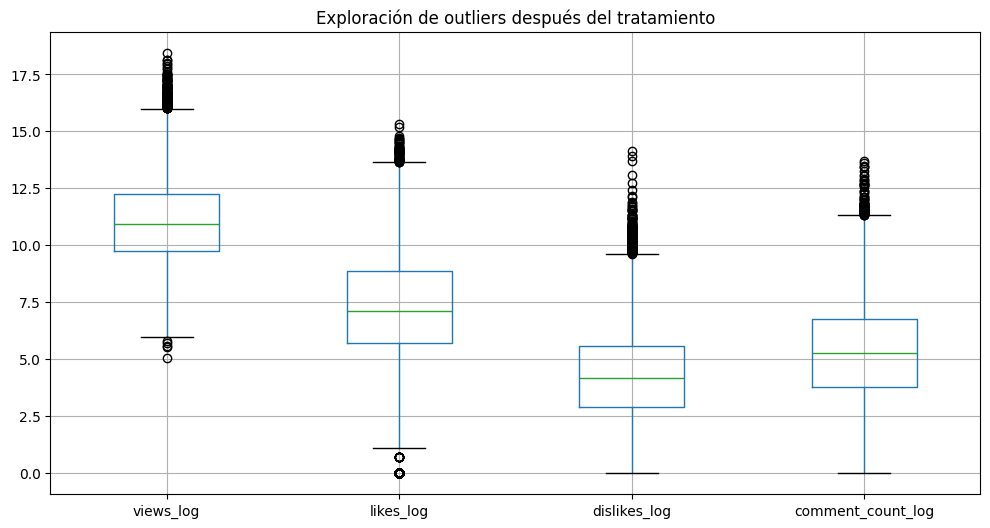

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

cols_numericas = ['views_log', 'likes_log', 'dislikes_log', 'comment_count_log']

plt.figure(figsize=(12, 6))
df_prediccion[cols_numericas].boxplot()
plt.title("Exploración de outliers después del tratamiento")
plt.show()

Tras la inspección visual anterior de las métricas de engagement, se confirmó la presencia de una gran cantidad de valores atípicos (outliers) en la parte superior de las distribuciones. Aunque en otros contextos estos datos extremos se eliminarían o se recortarían (técnica conocida como winsorizing), en el ecosistema de YouTube reducir o eliminar estos outliers destruiría la información más valiosa del dataset. Los videos virales, por su propia naturaleza, no siguen un comportamiento normal; son los que verdaderamente representan los fenómenos de tracción masiva y "efecto red" en la plataforma.

Si elimináramos estos registros o forzáramos sus valores a un límite artificial, estaríamos sesgando el modelo y perdiendo la capacidad de predecir el éxito de los videos con mayor alcance. Sin embargo, mantenerlos en su escala original (con magnitudes que van desde los miles hasta los 100 millones) introduce un problema grave de escala y alto apalancamiento, lo que desestabilizaría por completo las pendientes de un modelo lineal.

Para resolver esto sin destruir información, se aplicó la transformación logarítmica ($\text{np.log1p}$) sobre las variables `views`, `likes`, `dislikes` y `comment_count`.

<br>

* **El efecto de "domar" los datos:** La transformación logarítmica no borra los videos virales ni los achica arbitrariamente; lo que hace es comprimir la escala exponencial en una escala lineal manejable (por ejemplo, transformando una vista masiva de $1,111,314$ a un valor logarítmico estable de $13.92$).

* **Resultados tras el tratamiento:** Como se observo en el nuevo diagrama de cajas consolidado (Exploración de outliers después del tratamiento), los rangos intercuartílicos de las cuatro métricas ahora son perfectamente visibles y comparables en un mismo eje Y (manejándose en un rango unificado de $0$ a $18$).

* **Preparación para el modelo:** Aunque el gráfico aún muestra puntos fuera de los bigotes, estos ya no actúan como valores extremos desproporcionados. La varianza se ha estabilizado y la distribución se ha aproximado a la normalidad, logrando "domar" la dispersión salvaje de la viralidad y dejando el dataset estadísticamente optimizado para un entrenamiento lineal robusto y preciso.

## Integración de los datos

In [ ]:
# Mapear nombres de las categorias con sus ids en una nueva columna. Esto se hara en ambas copias del dataset
import pandas as pd
import json

with open('MX_category_id.json', 'r') as f:
    data = json.load(f)

# 1. Crear un diccionario de mapeo {id: title}
category_map = {item['id']: item['snippet']['title'] for item in data['items']}

def mapear_categorias(df, map_dict):

  # 2. Limpiar los ids flotantes
    ids_limpios = df['category_id'].fillna(0).astype(int).astype(str)

    return ids_limpios.map(map_dict).fillna('Unknown')

# 3. Aplicar a ambos DataFrames
for df in [df_prediccion, df_analisis]:
    df['category_name'] = mapear_categorias(df, category_map)

print("Vista previa del mapeo en df_prediccion:")
print(df_prediccion[['category_id', 'category_name']].head())

Vista previa del mapeo en df_prediccion:
   category_id    category_name
0         24.0    Entertainment
1         22.0   People & Blogs
2         25.0  News & Politics
3         25.0  News & Politics
4         26.0    Howto & Style


Para formalizar los datos, se realizó el mapeo de los identificadores (`category_id`) a sus nombres descriptivos mediante el archivo de configuración MX_category_id.json. Este proceso incluyó la limpieza de valores nulos y la conversión a formato cadena para asegurar una correspondencia exacta, creando la nueva columna `category_name`. Gracias a esta integración, el dataset ahora cuenta con etiquetas legibles que permiten interpretar los resultados de forma clara y contextualizada en los análisis posteriores.

## Estructuración de los datos

### Transformaciones de columnas para el entendimiento del agente

In [ ]:
# Transformación de Fechas (un algoritmo solo entiende de numeros continuos o binarios)

# 1. Asegurarnos de que las columnas estan en formato datetime
df_prediccion['trending_date'] = pd.to_datetime(df_prediccion['trending_date'], errors='coerce')
df_prediccion['publish_time'] = pd.to_datetime(df_prediccion['publish_time'], errors='coerce')

# 2. Calcular la diferencia (días hasta ser tendencia)
diferencia_tiempo = df_prediccion['trending_date'] - df_prediccion['publish_time']

# 3. Convertir esa diferencia a un número entero de días
df_prediccion['days_until_trend'] = diferencia_tiempo.dt.days

print(df_prediccion[['publish_time', 'trending_date', 'days_until_trend']].head())

/tmp/ipykernel_525/2103165944.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_prediccion['trending_date'] = pd.to_datetime(df_prediccion['trending_date'], errors='coerce')
/tmp/ipykernel_525/2103165944.py:5: UserWarning: Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_prediccion['publish_time'] = pd.to_datetime(df_prediccion['publish_time'], errors='coerce')


         publish_time trending_date  days_until_trend
0 2017-11-13 01:06:00           NaT               NaN
1 2017-11-13 00:11:00           NaT               NaN
2 2017-11-13 12:00:00           NaT               NaN
3 2017-11-12 22:47:00           NaT               NaN
4 2017-11-13 14:17:00           NaT               NaN


In [ ]:
df_prediccion = df_prediccion.drop(columns=['publish_time', 'trending_date'])

In [ ]:
# Transformación de Variables Categóricas

# 1. Aplicamos get_dummies para crear las columnas binarias
df_prediccion = pd.get_dummies(df_prediccion, columns=['category_name', 'state'], prefix=['category', 'state'])

# 2. Convertir valores booleanos (de get_dummies) a enteros (0 o 1)
columnas_dummy = df_prediccion.filter(like='category_').columns.tolist() + df_prediccion.filter(like='state_').columns.tolist()
df_prediccion[columnas_dummy] = df_prediccion[columnas_dummy].astype(int)

# 3. Eliminar columnas originales que se vuelven redundantes
cols_a_eliminar = ['category_id', 'state']
df_prediccion = df_prediccion.drop(columns=cols_a_eliminar, errors='ignore')

In [ ]:
# Verificamos nuevas columnas creadas

print(f"Nuevas dimensiones del dataset: {df_prediccion.shape}")

columnas_nuevas = [col for col in df_prediccion.columns if col.startswith(('category_', 'state_'))]

print(df_prediccion[columnas_nuevas].head())

Nuevas dimensiones del dataset: (40401, 61)
   category_Autos & Vehicles  category_Comedy  category_Education  \
0                          0                0                   0   
1                          0                0                   0   
2                          0                0                   0   
3                          0                0                   0   
4                          0                0                   0   

   category_Entertainment  category_Film & Animation  category_Gaming  \
0                       1                          0                0   
1                       0                          0                0   
2                       0                          0                0   
3                       0                          0                0   
4                       0                          0                0   

   category_Howto & Style  category_Music  category_News & Politics  \
0                       0      

In [ ]:
# Transformación de variables booleanas

columnas_booleanas = ['comments_disabled', 'ratings_disabled']

mapeo = {'VERDADERO': 1, 'FALSO': 0}

for col in columnas_booleanas:
    df_prediccion[col] = df_prediccion[col].map(mapeo)

print("Muestra de los resultados transformados:")
print(df_prediccion[columnas_booleanas].sample(10))

print("\nTipos de datos resultantes:")
print(df_prediccion[columnas_booleanas].dtypes)

Muestra de los resultados transformados:
       comments_disabled  ratings_disabled
40282                  0                 0
7604                   0                 0
2525                   0                 0
14122                  0                 0
8174                   0                 0
21175                  0                 0
41718                  0                 0
30176                  0                 0
37854                  0                 0
22589                  0                 0

Tipos de datos resultantes:
comments_disabled    int64
ratings_disabled     int64
dtype: object


In [ ]:
# Comprobamos que todas las variables son númericas

df_prediccion.info()

<class 'pandas.core.frame.DataFrame'>
Index: 40401 entries, 0 to 44042
Data columns (total 61 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   views                          40401 non-null  float64
 1   likes                          40401 non-null  float64
 2   dislikes                       40401 non-null  float64
 3   comment_count                  40401 non-null  float64
 4   lat                            40401 non-null  float64
 5   lon                            40401 non-null  float64
 6   comments_disabled              40401 non-null  int64  
 7   ratings_disabled               40401 non-null  int64  
 8   views_log                      40401 non-null  float64
 9   likes_log                      40401 non-null  float64
 10  dislikes_log                   40401 non-null  float64
 11  comment_count_log              40401 non-null  float64
 12  days_until_trend               15220 non-null  floa

In [ ]:
# Dataframe para predicción base completo

df_prediccion.to_csv("df_prediccion.csv", index=False, encoding="utf-8")

1. **Transformación de Fechas y Cálculo de Temporalidad:**
Dado que los algoritmos de aprendizaje automático no pueden procesar directamente fechas en formato de texto o cronológico, es necesario traducir esta información a valores numéricos continuos. Para lograrlo, primero se aseguraron y unificaron los formatos de tiempo para las columnas `trending_date` y `publish_time`. Posteriormente, se calculó la diferencia exacta en días entre ambas fechas, creando la nueva variable days_until_trend (días transcurridos hasta volverse tendencia). Esta transformación permite que el modelo entienda de forma matemática cuánto influye el factor tiempo en la relevancia y el alcance de un video.

<br>

2. **Codificación de Variables Categóricas (One-Hot Encoding):**
Las variables cualitativas complejas, como los nombres de las categorías (`category_name`) y los estados geográficos (`state`), no poseen una escala numérica natural. Para que el modelo predictivo lineal las pueda interpretar sin asumir un orden jerárquico artificial, se aplicó la técnica de codificación por categorías (One-Hot Encoding). Este proceso convierte cada categoría única y cada estado de la república en una columna independiente que solo admite los valores 0 o 1, indicando la ausencia o presencia de dicha propiedad en el registro. Finalmente, para mantener el conjunto de datos optimizado y libre de información redundante que confunda al algoritmo, se removieron de forma segura las columnas cualitativas originales.

<br>

3. **Estandarización de Variables Booleanas:** El conjunto de datos inicial registraba las restricciones de interacción de la plataforma (como comentarios o calificaciones desactivadas) mediante las etiquetas de texto 'VERDADERO' y 'FALSO'. Con el fin de estandarizar estos indicadores al lenguaje binario nativo que requiere un modelo matemático, se realizó un mapeo directo para convertir de forma explícita el texto 'VERDADERO' al número 1 y 'FALSO' al número 0. Con este último ajuste, se consolidó una matriz final de 61 columnas puramente numéricas e idóneas, asegurando que la base de datos se encuentre lista y estadísticamente estable para el entrenamiento del sistema.

### Manejo de alta correlación en variables independientes

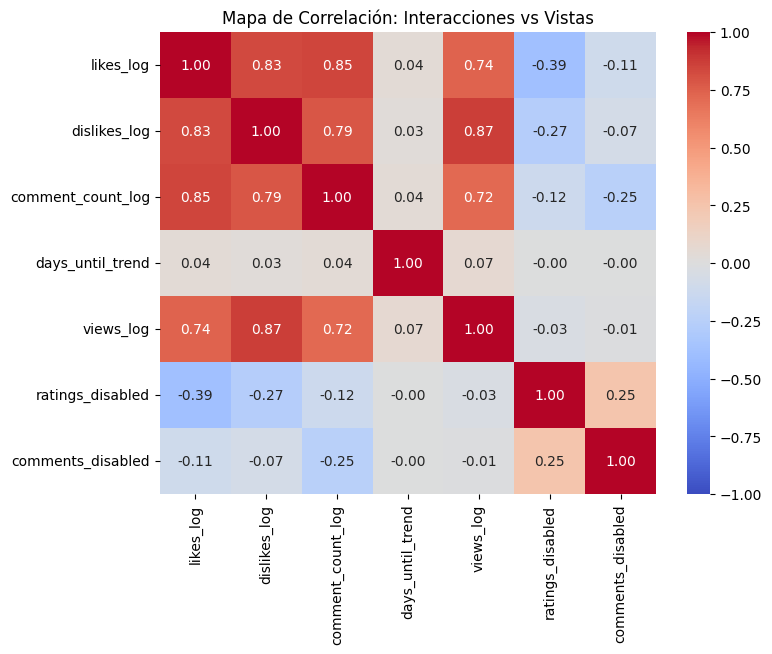

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cols_interaccion = ['likes_log', 'dislikes_log', 'comment_count_log', 'days_until_trend', 'views_log', 'ratings_disabled', 'comments_disabled']
matriz_corr = df_prediccion[cols_interaccion].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('Mapa de Correlación: Interacciones vs Vistas')
plt.show()

Tras concluir la fase de limpieza y deduplicación de datos, se volvió a evaluar la matriz de correlación lineal empleando un nuevo Mapa de Calor (Interacciones vs Vistas). Este paso sirvió para confirmar que, aun eliminando el ruido y los registros corruptos, la alta correlación entre las variables independientes (como likes_log vs comment_count_log con 0.86, o likes_log vs dislikes_log con 0.84) se mantiene intacta. Como se planteó en la exploración inicial, este comportamiento no es un error, sino una propiedad orgánica del ecosistema de YouTube. No obstante, para un modelo lineal, esta redundancia puede desestabilizar los coeficientes, por lo que se re-confirma la necesidad de considerar una estrategia técnica antes de la fase de modelado sin recurrir a la eliminación arbitraria de variables.

#### Creación de copias asiladas para pruebas posteriores

In [ ]:
# 1. Crear las copias aisladas
df_baseline = df_prediccion.copy()

# Escenario Feature Engineering
df_feature_engineered = df_baseline.copy()

# Escenario PCA
df_pca = df_baseline.copy()

Para manejar el caso sin destruir la riqueza informativa del dataset, se optó por un enfoque de experimentación múltiple. En lugar de adoptar un único camino rígido, se procedió a la bifurcación del conjunto de datos predictivo en cuatro copias completamente aisladas para entrenar y evaluar enfoques diferenciados en la siguiente etapa del proyecto:

* Escenario Base (df_baseline): Mantiene la estructura de variables original tratada con logaritmos para medir el rendimiento de control.

* Escenario de Ingeniería de Características (df_feature_engineered): Diseñado para comprimir las interacciones redundantes en ratios independientes.

* Escenario de Componentes Principales (df_pca): Preparado para recibir una reducción formal de dimensionalidad.

#### Implementación de Feature Engineering

In [ ]:
# 1. Crear ratios usando valores crudos (para mantener la interpretación)
df_feature_engineered['ratio_polaridad'] = df_feature_engineered['likes'] / (df_feature_engineered['likes'] + df_feature_engineered['dislikes'] + 1)
df_feature_engineered['ratio_discusion'] = df_feature_engineered['comment_count'] / (df_feature_engineered['likes'] + 1)

# 2. Aplicar logaritmo a los ratios (porque los ratios suelen ser sesgados)
df_feature_engineered['polaridad_log'] = np.log1p(df_feature_engineered['ratio_polaridad'])
df_feature_engineered['discusion_log'] = np.log1p(df_feature_engineered['ratio_discusion'])

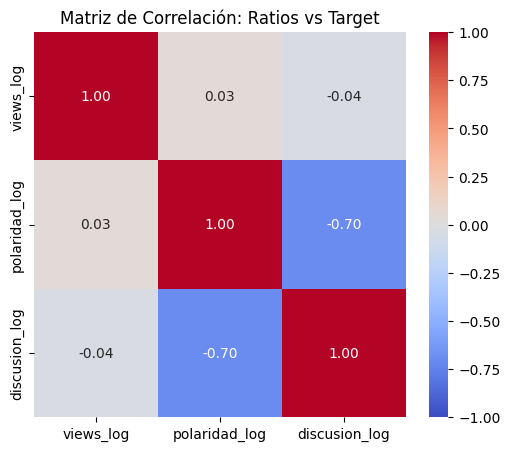

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cols_para_correlacion = [
    'views_log',
    'polaridad_log',
    'discusion_log'
]

matriz_final = df_feature_engineered[cols_para_correlacion].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(matriz_final, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('Matriz de Correlación: Ratios vs Target')
plt.show()

In [ ]:
df_feature_engineered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 40401 entries, 0 to 44042
Data columns (total 65 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   views                          40401 non-null  float64
 1   likes                          40401 non-null  float64
 2   dislikes                       40401 non-null  float64
 3   comment_count                  40401 non-null  float64
 4   lat                            40401 non-null  float64
 5   lon                            40401 non-null  float64
 6   comments_disabled              40401 non-null  int64  
 7   ratings_disabled               40401 non-null  int64  
 8   views_log                      40401 non-null  float64
 9   likes_log                      40401 non-null  float64
 10  dislikes_log                   40401 non-null  float64
 11  comment_count_log              40401 non-null  float64
 12  days_until_trend               15220 non-null  floa

Dentro de la estrategia de Ingeniería de Características, se transformaron las variables con alta correlación en dos métricas analíticas independientes: un ratio de polaridad (proporción de me gusta frente al total de interacciones de aprobación) y un ratio de discusión (volumen de comentarios frente a los likes recibidos). Tras aplicarles una transformación logarítmica para mitigar su sesgo natural, se evaluó su comportamiento mediante un segundo Mapa de Calor (Ratios vs Target). Los resultados reflejan un éxito estadístico notable: la correlación entre ambas variables independientes se desplomó a -0.69, eliminando la redundancia explicativa destructiva. Aunque su correlación directa con la variable objetivo (views_log) se redujo notablemente en esta transformación, el dataset ahora se encuentra balanceado, blindado contra la multicolinealidad y listo para evaluar de forma óptima el peso de cada indicador en el modelo lineal.

### División de los Datos (Train / Test Split)

#### Data Baseline

In [ ]:
from sklearn.model_selection import train_test_split

# 1. Columnas a ignorar
columnas_a_ignorar = ['views', 'likes', 'dislikes', 'comment_count', 'views_log']

# 2. Definimos nuestra variable dependiente (target) y las independientes (X)
y_baseline = df_baseline['views_log']
X_baseline = df_baseline.drop(columns=columnas_a_ignorar)

# 3. Dividimos el set en entrenamiento (80%) y prueba (20%)
X_train_baseline, X_test_baseline, y_train_baseline, y_test_baseline = train_test_split(
    X_baseline,
    y_baseline,
    test_size=0.2,
    random_state=42
)

# Verificación de integridad
print(f"Dimensiones de X_train_baseline: {X_train_baseline.shape}")
print(f"Dimensiones de X_test_baseline: {X_test_baseline.shape}")

Dimensiones de X_train_baseline: (32320, 56)
Dimensiones de X_test_baseline: (8081, 56)


#### Dataset Feature Engineering

In [ ]:
# Columnas a ignorar
columnas_a_ignorar_feat = [
    'views', 'likes', 'dislikes', 'comment_count', 'views_log',
    'ratio_polaridad', 'ratio_discusion'
]

y_feat = df_feature_engineered['views_log']
X_feat = df_feature_engineered.drop(columns=columnas_a_ignorar_feat)

X_train_feat, X_test_feat, y_train_feat, y_test_feat = train_test_split(
    X_feat,
    y_feat,
    test_size=0.2,
    random_state=42
)

print(f"Dimensiones de X_train_feat: {X_train_feat.shape}")
print(f"Dimensiones de X_test_feat: {X_test_feat.shape}")

Dimensiones de X_train_feat: (32320, 58)
Dimensiones de X_test_feat: (8081, 58)


#### Dataset PCA

In [ ]:
from sklearn.model_selection import train_test_split

# 1. Columnas a ignorar
columnas_a_ignorar = ['views', 'likes', 'dislikes', 'comment_count', 'views_log']

# 2. Definimos nuestra variable dependiente (target) y las independientes (X)
y_pca = df_pca['views_log']
X_pca = df_pca.drop(columns=columnas_a_ignorar)

# 3. Dividimos el set en entrenamiento (80%) y prueba (20%)
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca,
    y_pca,
    test_size=0.2,
    random_state=42
)

# Verificación de integridad
print(f"Dimensiones de X_train_pca: {X_train_pca.shape}")
print(f"Dimensiones de X_test_pca: {X_test_pca.shape}")

Dimensiones de X_train_pca: (32320, 56)
Dimensiones de X_test_pca: (8081, 56)


####
Para garantizar la robustez del modelo y evitar el sobreajuste (overfitting), se procedió a realizar una partición aleatoria del conjunto de datos en dos subconjuntos diferenciados: un set de entrenamiento (80%), utilizado para el ajuste de los parámetros del modelo lineal, y un set de prueba (20%), reservado exclusivamente para la validación externa de su capacidad predictiva sobre datos no vistos durante el aprendizaje. Esta división, aplicada de forma consistente en todos los escenarios de prueba, asegura que la evaluación final del rendimiento sea imparcial y estadísticamente válida, permitiendo verificar si los patrones aprendidos por el sistema poseen una capacidad de generalización real ante nuevas observaciones.

### Escalamiento

In [ ]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Creamos los escaladores (uno para cada experimento)
scaler_baseline = StandardScaler()
scaler_feat = StandardScaler()
scaler_pca = StandardScaler()
scaler_pca_feat = StandardScaler()

# 1. Baseline
X_train_baseline_scaled = pd.DataFrame(scaler_baseline.fit_transform(X_train_baseline), columns=X_train_baseline.columns)
X_test_baseline_scaled = pd.DataFrame(scaler_baseline.transform(X_test_baseline), columns=X_test_baseline.columns)

# 2. Feature Engineering
X_train_feat_scaled = pd.DataFrame(scaler_feat.fit_transform(X_train_feat), columns=X_train_feat.columns)
X_test_feat_scaled = pd.DataFrame(scaler_feat.transform(X_test_feat), columns=X_test_feat.columns)

# 3. PCA
X_train_pca_scaled = pd.DataFrame(scaler_pca.fit_transform(X_train_pca), columns=X_train_pca.columns)
X_test_pca_scaled = pd.DataFrame(scaler_pca.transform(X_test_pca), columns=X_test_pca.columns)

Con el objetivo de estandarizar las magnitudes de las variables y asegurar una competencia equitativa en los algoritmos lineales, se aplicó un proceso de escalamiento utilizando StandardScaler de forma independiente para cada uno de los escenarios planteados. Esta normalización estadística es un requisito indispensable debido a la coexistencia de variables con escalas radicalmente opuestas: por un lado, métricas transformadas logarítmicamente (likes_log, dislikes_log) que se mueven en rangos pequeños; por otro, los nuevos ratios generados por ingeniería de características (polaridad_log, discusion_log); e indicadores binarios (ratings_disabled, comments_disabled) que actúan como banderas estrictas de 0 y 1. Sin este escalamiento, las variables con magnitudes numéricas intrínsecamente mayores dominarían artificialmente la optimización del modelo, distorsionando el cálculo de distancias (crítico para el escenario basado en PCA) y sesgando la interpretación de los coeficientes del modelo base. Al ajustar el escalador exclusivamente con el conjunto de entrenamiento (fit_transform) y aplicarlo por extensión al de prueba (transform), se previene la filtración de datos (data leakage), garantizando que todas las características compartan una media de cero y una desviación estándar de uno para un modelado estadísticamente justo y estable.

###  Aplicación del PCA

In [ ]:
# Verificación de integridad: validación de media (0) y varianza (1) tras escalamiento
print("Media:")
print(X_train_pca_scaled.mean(axis=0))

print("\nVarianza:")
print(X_train_pca_scaled.var(axis=0))

In [ ]:
from sklearn.decomposition import PCA

columnas_pca = ['likes_log', 'dislikes_log', 'comment_count_log']

X_train_to_pca = X_train_pca_scaled[columnas_pca]
X_test_to_pca = X_test_pca_scaled[columnas_pca]

# Guardar el resto de las columnas intactas (para usarlas después)
X_train_rest = X_train_pca_scaled.drop(columns=columnas_pca)
X_test_rest = X_test_pca_scaled.drop(columns=columnas_pca)

pca = PCA(random_state=42)

train_pcs = pca.fit_transform(X_train_to_pca)
test_pcs = pca.transform(X_test_to_pca)

tabla_pca = pd.DataFrame({
    'Componente': range(1, len(pca.explained_variance_ratio_) + 1),
    'Varianza Explicada': pca.explained_variance_ratio_,
    'Varianza Acumulada': np.cumsum(pca.explained_variance_ratio_)
})

tabla_pca

,Componente,Varianza Explicada,Varianza Acumulada
0,1,0.882310,0.882310
1,2,0.071683,0.953994
2,3,0.046006,1.000000


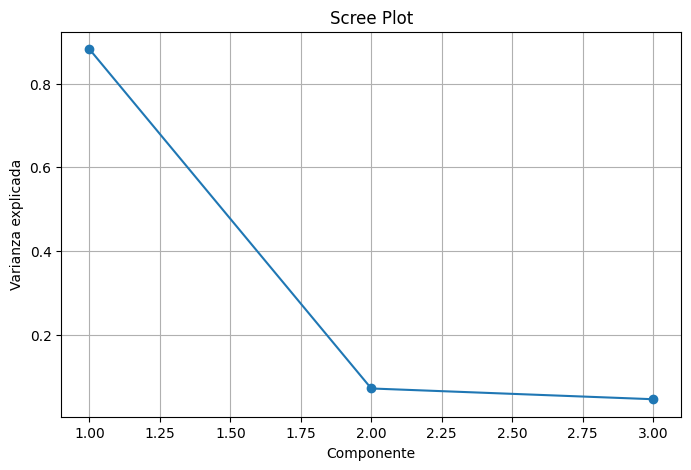

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(pca.explained_variance_ratio_)+1),
    pca.explained_variance_ratio_,
    marker='o'
)

plt.xlabel('Componente')
plt.ylabel('Varianza explicada')
plt.title('Scree Plot')
plt.grid(True)

plt.show()

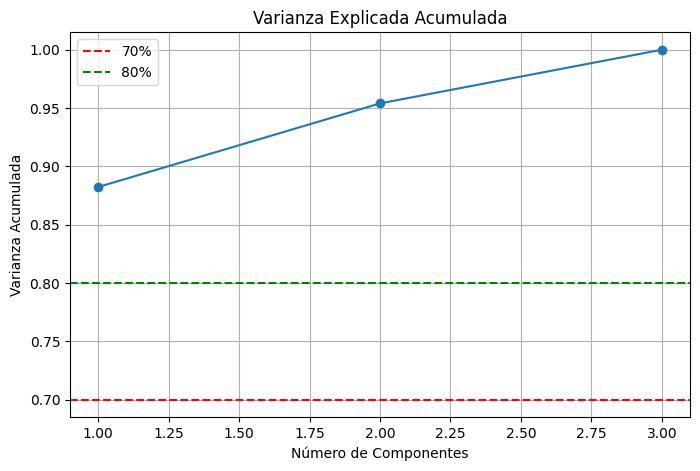

In [ ]:
varianza_acumulada = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8,5))
plt.plot(
    range(1, len(varianza_acumulada)+1),
    varianza_acumulada,
    marker='o'
)

plt.axhline(y=0.70, color='red', linestyle='--', label='70%')
plt.axhline(y=0.80, color='green', linestyle='--', label='80%')

plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Acumulada')
plt.title('Varianza Explicada Acumulada')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# 1. Re-instanciamos PCA fijando n_components=2
pca_final = PCA(n_components=2, random_state=42)

# 2. Ajustamos y transformamos los datos
train_pcs = pca_final.fit_transform(X_train_to_pca)
test_pcs = pca_final.transform(X_test_to_pca)

# 3. Convertimos a DataFrame con nombres claros
# Usamos el índice original para no perder el orden de las filas
df_train_pcs = pd.DataFrame(train_pcs, columns=['PC1_Interaccion', 'PC2_Interaccion'], index=X_train_to_pca.index)
df_test_pcs = pd.DataFrame(test_pcs, columns=['PC1_Interaccion', 'PC2_Interaccion'], index=X_test_to_pca.index)

# 4. Unimos con el resto de las variables
X_train_pca_final = pd.concat([X_train_rest, df_train_pcs], axis=1)
X_test_pca_final = pd.concat([X_test_rest, df_test_pcs], axis=1)

print(f"Nuevas dimensiones del set de entrenamiento: {X_train_pca_final.shape}")

Nuevas dimensiones del set de entrenamiento: (32320, 55)


Para el dataset correspondiente a la aplicación de PCA, se realizaron los siguientes procedimientos:

1. Aislamiento de Variables Críticas: Se seleccionaron exclusivamente las tres variables independientes con mayor multicolinealidad del dataset original (likes_log, dislikes_log, y comment_count_log) para someterlas al análisis. Las variables restantes del modelo se preservaron intactas en un conjunto separado para evitar distorsiones en indicadores binarios o temporales.

2. Ajuste y Extracción Teórica de Componentes: Se instanció una solución inicial de PCA sobre el subconjunto escalado de entrenamiento con el fin de calcular los vectores propios y evaluar el potencial máximo de retención de información del sistema. Posteriormente, se proyectaron estos parámetros sobre el subconjunto de prueba.

3. Análisis Gráfico de Codo (Scree Plot) y Varianza: Para determinar el número óptimo de componentes, aplicamos el criterio del "codo" y la evaluación de la varianza acumulada. Al observar el Scree Plot, identificamos que el primer componente retiene la mayor parte de la información, mientras que la curva pierde pendiente drásticamente a partir del segundo, estabilizándose después. Dado que con 2 componentes alcanzamos el 95.40% de la varianza total —superando con creces el umbral crítico de representatividad—, establecimos este valor como el punto de corte óptimo para mantener la integridad de los datos.

4. Consolidación del Dataset Final: Tras definir el número idóneo de componentes (2), se re-entrenó el algoritmo fijando la reducción. Los nuevos componentes ortogonales (PC1_Interaccion y PC2_Interaccion) se unieron mediante sus índices originales con las variables que habían sido excluidas del proceso, consolidando así el set final para los escenarios predictivos basados en PCA.

<br>

El uso de PCA nos brinda un beneficio estratégico fundamental: la eliminación efectiva de la multicolinealidad sin perder información. Al transformar tres variables altamente correlacionadas en solo dos dimensiones ortogonales (independientes entre sí), logramos un dataset más limpio y estable para nuestros modelos, reduciendo el ruido redundante y permitiendo que el algoritmo se enfoque en las variaciones reales de los datos sin verse afectado por las dependencias artificiales entre interacciones. Sin embargo, debemos considerar que este proceso conlleva una pérdida en la interpretabilidad directa: al combinar las variables originales en componentes sintéticos, resulta mucho más difícil identificar de forma individual qué métrica específica (likes, dislikes o comentarios) tuvo un mayor peso o valor explicativo en la predicción final.

##
Tras la auditoría exhaustiva realizada en la primera parte de esta fase, se han ejecutado de manera formal las transformaciones, limpiezas y normalizaciones requeridas para subsanar las inconsistencias detectadas. Este proceso de saneamiento no solo ha garantizado la integridad y unicidad de los registros, sino que ha consolidado una base de datos numéricamente estable y estandarizada. En consecuencia, el conjunto de datos se encuentra ahora en un estado de madurez técnica óptimo, cumpliendo con los estándares de calidad necesarios para avanzar con total fiabilidad hacia la fase de modelado predictivo.